 ### ml workflow
 
 1. Look at the big picture ---> What type for marketing is more effective for sales?
 2. Get the data.
 3. Discover and visualize the data to gain insights.
 4. Prepare the data for Machine Learning algorithms.
 5. Select and train model.
 6. Fine-tune model.
 7. Deploy & iterate

### 3. Discover and  visualize the data to gain insights

In [15]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


advertising_df = pl.read_csv('Advertising.csv')


In [16]:
# Peep

advertising_df.head(6)



,TV,Radio,Newspaper,Sales
i64,f64,f64,f64,f64
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2


In [17]:
advertising_df.shape  #200 rows, 5 columns

(200, 5)

In [18]:
# count: amount of rows
# null_count: missing values
# mean: average $1000 spent

descr = advertising_df.describe()[:3]
max_values = advertising_df.max()
min_values = advertising_df.min()

print(descr)
print(max_values)
print(min_values)

shape: (3, 6)
┌────────────┬───────┬──────────┬────────┬───────────┬─────────┐
│ statistic  ┆       ┆ TV       ┆ Radio  ┆ Newspaper ┆ Sales   │
│ ---        ┆ ---   ┆ ---      ┆ ---    ┆ ---       ┆ ---     │
│ str        ┆ f64   ┆ f64      ┆ f64    ┆ f64       ┆ f64     │
╞════════════╪═══════╪══════════╪════════╪═══════════╪═════════╡
│ count      ┆ 200.0 ┆ 200.0    ┆ 200.0  ┆ 200.0     ┆ 200.0   │
│ null_count ┆ 0.0   ┆ 0.0      ┆ 0.0    ┆ 0.0       ┆ 0.0     │
│ mean       ┆ 100.5 ┆ 147.0425 ┆ 23.264 ┆ 30.554    ┆ 14.0225 │
└────────────┴───────┴──────────┴────────┴───────────┴─────────┘
shape: (1, 5)
┌─────┬───────┬───────┬───────────┬───────┐
│     ┆ TV    ┆ Radio ┆ Newspaper ┆ Sales │
│ --- ┆ ---   ┆ ---   ┆ ---       ┆ ---   │
│ i64 ┆ f64   ┆ f64   ┆ f64       ┆ f64   │
╞═════╪═══════╪═══════╪═══════════╪═══════╡
│ 200 ┆ 296.4 ┆ 49.6  ┆ 114.0     ┆ 27.0  │
└─────┴───────┴───────┴───────────┴───────┘
shape: (1, 5)
┌─────┬─────┬───────┬───────────┬───────┐
│     ┆ TV  ┆ Radio ┆ N

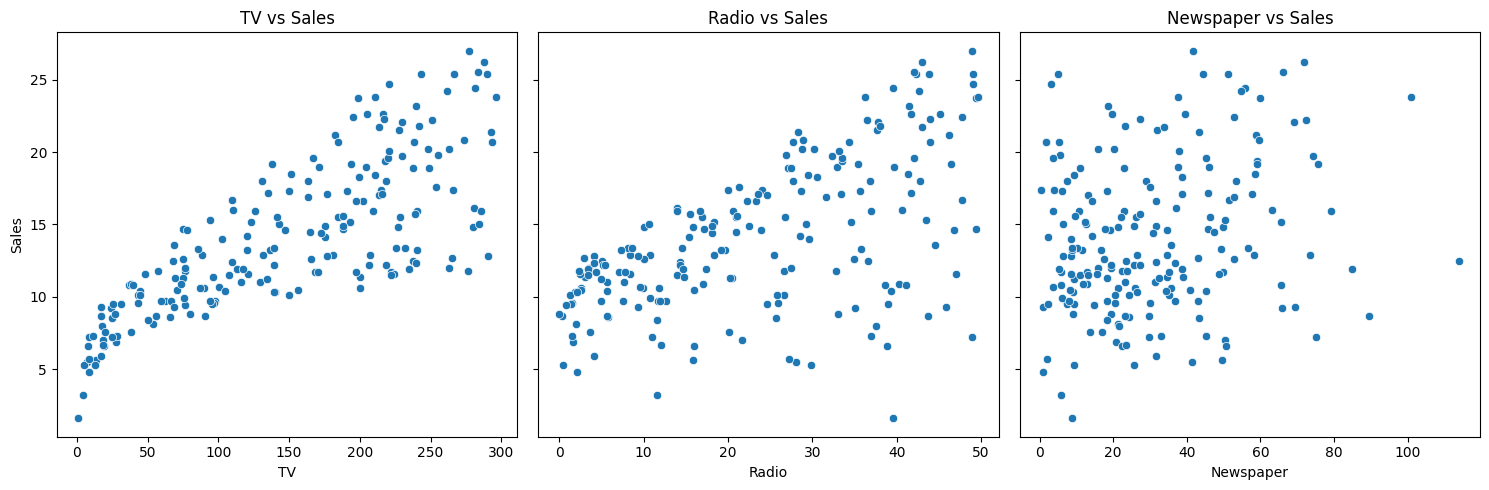

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)
channels = ["TV", "Radio", "Newspaper"]

for i, channel in enumerate(channels):

    sns.scatterplot(
        data=advertising_df, 
        x=channel, 
        y="Sales", 
        ax=axes[i]
        )
    
    axes[i].set_title(f"{channel} vs Sales")

plt.tight_layout()
plt.show()


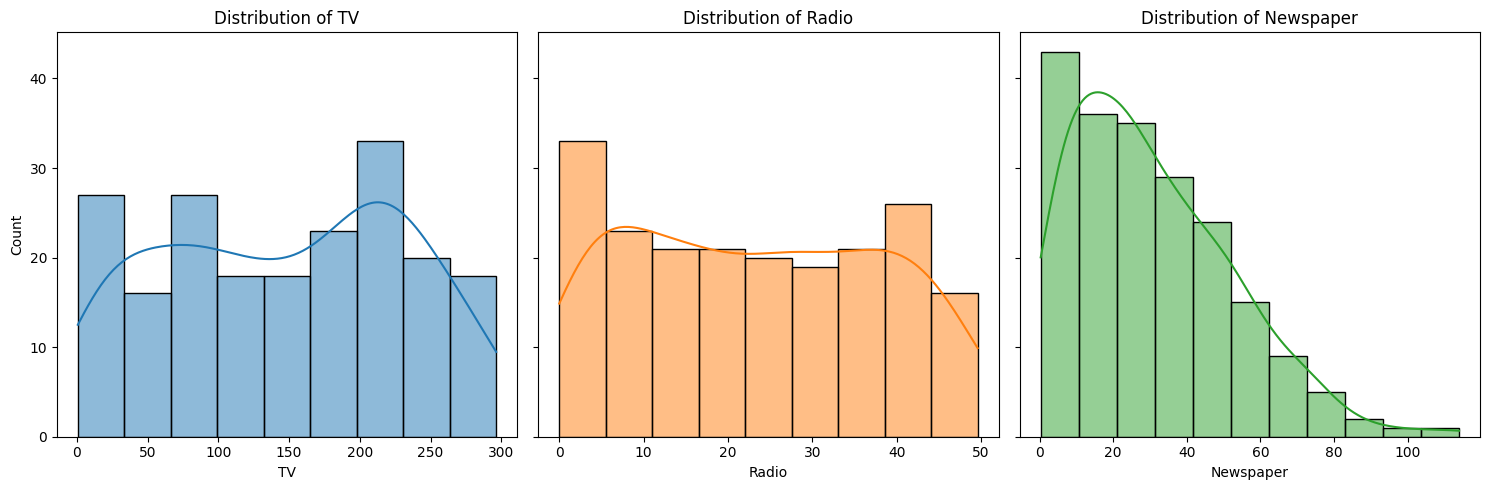

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, channel in enumerate(channels):
    sns.histplot(data=advertising_df, x=channel, kde=True, ax=axes[i], color=f"C{i}")
    axes[i].set_title(f"Distribution of {channel}")

# Adjust layout
plt.tight_layout()
plt.show()

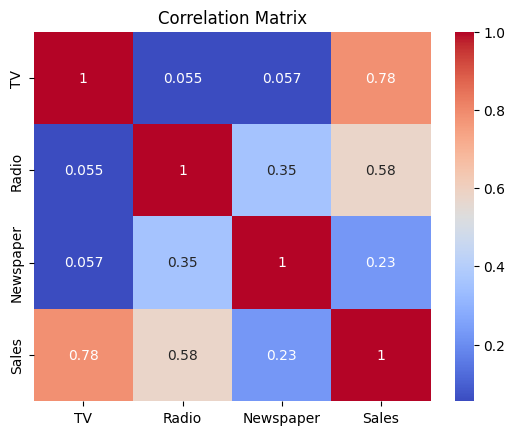

Correlation Matrix:
shape: (4, 4)
┌──────────┬──────────┬───────────┬──────────┐
│ TV       ┆ Radio    ┆ Newspaper ┆ Sales    │
│ ---      ┆ ---      ┆ ---       ┆ ---      │
│ f64      ┆ f64      ┆ f64       ┆ f64      │
╞══════════╪══════════╪═══════════╪══════════╡
│ 1.0      ┆ 0.054809 ┆ 0.056648  ┆ 0.782224 │
│ 0.054809 ┆ 1.0      ┆ 0.354104  ┆ 0.576223 │
│ 0.056648 ┆ 0.354104 ┆ 1.0       ┆ 0.228299 │
│ 0.782224 ┆ 0.576223 ┆ 0.228299  ┆ 1.0      │
└──────────┴──────────┴───────────┴──────────┘


In [21]:
# Heatmap (optional, using Matplotlib and Seaborn)

names = ["TV", "Radio", "Newspaper", "Sales"]
correlation_matrix = advertising_df.select(names).corr()


sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=names, yticklabels=names)
plt.title("Correlation Matrix")
plt.show()


print("Correlation Matrix:")
print(correlation_matrix)



### 4. Prepare data for algorithm - example, BMI start playing around with data


In [22]:
X = advertising_df.select({"TV", "Radio", "Newspaper"}).to_numpy() # convert to array, måste ha förklarat av supervised learning är
y = advertising_df.select("Sales").to_numpy().ravel() #convert to array & flatten



In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes of the splits
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (160, 3)
Testing set size: (40, 3)


### 5. Train model

In [24]:
# Selection model: linear regression
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Display the model's intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 2.9790673381226362
Coefficients: [0.00276111 0.18919505 0.04472952]


### Evaluate

In [25]:

# Test model
y_pred = model.predict(X_test)


compare_df = pl.DataFrame(
    {
        "Predictions": y_pred,
        "Answers": y_test

    }

)


print(compare_df)

shape: (40, 2)
┌─────────────┬─────────┐
│ Predictions ┆ Answers │
│ ---         ┆ ---     │
│ f64         ┆ f64     │
╞═════════════╪═════════╡
│ 16.408024   ┆ 16.9    │
│ 20.889882   ┆ 22.4    │
│ 21.553843   ┆ 21.4    │
│ 10.608503   ┆ 7.3     │
│ 22.112373   ┆ 24.7    │
│ …           ┆ …       │
│ 20.137663   ┆ 20.7    │
│ 14.05514    ┆ 11.6    │
│ 20.854112   ┆ 20.8    │
│ 11.017444   ┆ 11.9    │
│ 4.568996    ┆ 6.9     │
└─────────────┴─────────┘


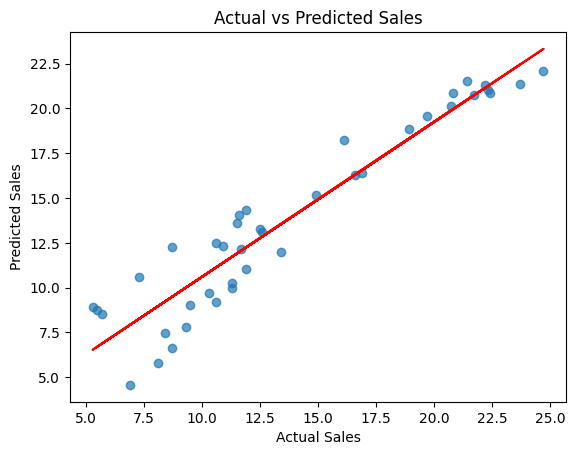

In [26]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Adding a line of best fit
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m * y_test + b, color='red')

plt.show()

In [27]:
mse = mean_squared_error(y_test, y_pred)
print("Mean squared error", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared", r2)



Mean squared error 3.1740973539761055
R-squared 0.899438024100912


In [28]:
# Display coefficients for each feature
features = ["TV", "Radio", "Newspaper"]
coefficients = model.coef_

print("Feature importance by coefficent")
for feature, coef in zip(features, coefficients):
    print(f"{feature}: {coef}")


Feature importance by coefficent
TV: 0.0027611143413670772
Radio: 0.18919505423437666
Newspaper: 0.0447295174687163


In [34]:
tv_budget = 33_400
radio_budget = 22_200
newspaper_budget = 150_00

budget = np.array([[tv_budget, radio_budget, newspaper_budget]])

model.predict(budget)

array([4966.27325237])